In [ ]:
!pip install upsetplot

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import re
from difflib import SequenceMatcher
from pathlib import Path
from matplotlib.ticker import MaxNLocator
from upsetplot import UpSet, from_indicators
import numpy as np

BASE_DIR = Path("../Data")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
TOOL_ALIASES = {
    "googleacademico": "googlescholar",
    "googlescholar": "googlescholar",
    "google scholar": "googlescholar",
    "lens": "lens",
    "litmaps": "litmaps",
    "litmap": "litmaps",
    "researchrabbit": "researchrabbit",
    "semanticscholar": "semanticscholar",
    "semantic scholar": "semanticscholar",
    "openalex": "openalex",
    "opencitations": "opencitations",
    "snowmap": "snowmap"
}

ALL_TOOLS = [
    "googlescholar",
    "lens",
    "litmaps",
    "researchrabbit",
    "semanticscholar",
    "openalex",
    "opencitations",
    "snowmap"
]

#normalization
def normalize_doi(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()

    if s in {"", "nan", "none", "null", "x"}:
        return None

    s = s.replace("https://doi.org/", "")
    s = s.replace("http://doi.org/", "")
    s = s.replace("https://dx.doi.org/", "")
    s = s.replace("http://dx.doi.org/", "")
    s = s.replace("doi.org/", "")
    s = s.replace("doi:", "")
    s = s.strip()

    # cerca un DOI anche dentro stringhe più lunghe
    m = re.search(r"10\.\S+", s)
    if not m:
        return None

    s = m.group(0)
    s = s.rstrip(" .;,)")
    return s or None

def normalize_title(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s or None

#finding columns
DOI_COL_CANDIDATES = [
    "doi", "DOI", "doi_norm", "document_doi", "paper_doi", "work_doi", "citing", "externalIds"
]

TITLE_COL_CANDIDATES = [
    "title", "Title", "paper_title", "document_title", "article_title",
    "display_name", "work_title", "titulo"
]


def find_doi_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in DOI_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "doi" in c.lower():
            return c

    return None


def find_title_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in TITLE_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "title" in c.lower() or "titulo" in c.lower():
            return c

    return None


#read each csv

def read_csv_with_fallback(csv_path: Path):
    for sep in [",", ";", "\t"]:
        try:
            return pd.read_csv(csv_path, sep=sep)
        except Exception:
            pass

    return pd.read_csv(csv_path)

def prepare_normalized_df(csv_path: Path, verbose=True):
    df = read_csv_with_fallback(csv_path)
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    doi_col = find_doi_column(df)
    title_col = find_title_column(df)

    #warning
    if verbose:
        if doi_col is None:
            print(f"[WARNING] {csv_path.name} → colonna DOI NON trovata")
        if title_col is None:
            print(f"[WARNING] {csv_path.name} → colonna TITLE NON trovata")

    if doi_col is not None:
        df["doi_norm"] = df[doi_col].apply(normalize_doi)
    else:
        df["doi_norm"] = None

    if title_col is not None:
        df["title_norm"] = df[title_col].apply(normalize_title)
    else:
        df["title_norm"] = None

    return df, doi_col, title_col

def extract_tool_from_filename(filename):
    stem = Path(filename).stem.lower()
    if "nossatool" in stem:
        return "nossatool"
    if "our_tool" in stem:
        return "our_tool"
    if "snowmap" in stem:
        return "snowmap"

    # General case: remove "artigoXX_" prefix
    parts = stem.split('_', 1)
    if len(parts) > 1 and parts[0].startswith("artigo"):
        return parts[1]

    # Fallback if no specific pattern matched
    return stem



### **FUNCTION FOR ANALYSIS OF MISSING DATA**

In [ ]:
MISSING_TOKENS = {
    "", "nan", "none", "null", "na", "n/a", "x", "-",
    "(missing journal)", "(missing abstract)", "(missing year)",
    "(missing doi)", "(missing abstract)"
}
MISSING_TOKENS = {t.lower() for t in MISSING_TOKENS}

SOURCE_COL_BY_TOOL = {
    "googlescholar": "Source",
    "lens": "Source Title",
    "litmaps": "Journal",
    "researchrabbit": "Journal",
    "openalex": "primary_location.source.display_name",
    "semanticscholar": "venue",
    "snowmap": "Venue",
    # "opencitations": None,
}

MISSING_COL_MAP = {
    "missing_doi_pct": "DOI",
    "missing_abstract_pct": "Abstract",
    "missing_venue_pct": "Venue",
    "missing_cited_by_pct": "Cited by",
    "missing_year_pct": "Year",
}

SLR_ORDER = ["SLR 1", "SLR 2", "SLR 3", "SLR 4"]


def is_missing_value(x):
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    return s in MISSING_TOKENS


def pct_missing(series: pd.Series) -> float:
    if series is None or len(series) == 0:
        return 0.0
    s = series.astype(str).str.strip().str.lower()
    return s.isin(MISSING_TOKENS).mean() * 100


def extract_tool_from_filename(filename):
    stem = Path(filename).stem.lower()

    if "nossatool" in stem:
        return "nossatool"
    if "our_tool" in stem:
        return "our_tool"
    if "snowmap" in stem:
        return "snowmap"

    parts = stem.split("_", 1)
    if len(parts) > 1 and parts[0].startswith("artigo"):
        return parts[1]

    return stem


def normalize_tool_name(tool_raw):
    return TOOL_ALIASES.get(str(tool_raw).lower().strip(), str(tool_raw).lower().strip())


def find_column_by_candidates(df, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None


def build_missing_summary_for_file(csv_path: Path, verbose=True):
    try:
        df = read_csv_with_fallback(csv_path).copy()
        df.columns = [c.strip() for c in df.columns]
    except Exception as e:
        return {
            "file": csv_path.name,
            "tool": normalize_tool_name(extract_tool_from_filename(csv_path.name)),
            "rows_total": 0,
            "missing_doi_pct": 0.0,
            "missing_abstract_pct": 0.0,
            "missing_venue_pct": 0.0,
            "missing_cited_by_pct": 0.0,
            "missing_year_pct": 0.0,
            "error": str(e),
        }

    tool = normalize_tool_name(extract_tool_from_filename(csv_path.name))

    doi_col = find_doi_column(df)
    title_col = find_title_column(df)

    abstract_col = find_column_by_candidates(df, [
        "abstract", "Abstract", "summary", "description"
    ])

    year_col = find_column_by_candidates(df, [
        "year", "Year", "publication_year", "publicationYear", "Publication Year", "creation"
    ])

    cited_by_col = find_column_by_candidates(df, [
        "Cited By", "Cited by", "cited_by_count", "citationCount", "cited_by", "Citing Works Count"
    ])

    venue_col = SOURCE_COL_BY_TOOL.get(tool)

    if verbose:
        print(f"\n[FILE] {csv_path.name}")
        print(f" tool={tool}")
        print(f" doi_col={doi_col}")
        print(f" abstract_col={abstract_col}")
        print(f" venue_col={venue_col if venue_col in df.columns else None}")
        print(f" cited_by_col={cited_by_col}")
        print(f" year_col={year_col}")

    out = {
        "file": csv_path.name,
        "tool": tool,
        "rows_total": len(df),
        "missing_doi_pct": pct_missing(df[doi_col]) if doi_col in df.columns else 100.0,
        "missing_abstract_pct": pct_missing(df[abstract_col]) if abstract_col in df.columns else 100.0,
        "missing_venue_pct": pct_missing(df[venue_col]) if venue_col in df.columns else 100.0,
        "missing_cited_by_pct": pct_missing(df[cited_by_col]) if cited_by_col in df.columns else 100.0,
        "missing_year_pct": pct_missing(df[year_col]) if year_col in df.columns else 100.0,
        "error": None,
    }

    return out


def analyze_missing_in_folder(folder_path: Path, verbose=True):
    csv_files = sorted(
        [
            p for p in folder_path.iterdir()
            if p.is_file()
            and p.suffix.lower() == ".csv"
            and "artigos_relevantes" not in p.stem.lower()
            and p.stem.lower() != "metadados_por_ferramenta"
            and p.stem.lower() != "matriz_metadados_por_ferramenta"
            and p.stem.lower() != "g-t_artigo01"
        ]
    )

    rows = []
    for csv_path in csv_files:
        rows.append(build_missing_summary_for_file(csv_path, verbose=verbose))

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values("tool").reset_index(drop=True)

    return df


def prepare_missing_plot_df(missing_summary_df, slr_name):
    df = missing_summary_df.copy()
    df["slr"] = slr_name
    return df


def combine_missing_summaries(*dfs):
    valid = [df.copy() for df in dfs if df is not None and not df.empty]
    if not valid:
        return pd.DataFrame()
    out = pd.concat(valid, ignore_index=True)
    out["slr"] = pd.Categorical(out["slr"], categories=SLR_ORDER, ordered=True)
    return out.sort_values(["slr", "tool"]).reset_index(drop=True)


def plot_missing_by_field_and_tool(missing_summary_df):
    if missing_summary_df.empty:
        print("Nessun dato da plottare.")
        return

    plot_df = (
        missing_summary_df
        .groupby("tool", as_index=True)[list(MISSING_COL_MAP.keys())]
        .mean()
        .T
    )

    plot_df.index = [MISSING_COL_MAP[idx] for idx in plot_df.index]

    fields = plot_df.index.tolist()
    tools = plot_df.columns.tolist()

    x = np.arange(len(fields))
    width = min(0.18, 0.9 / max(len(tools), 1))

    plt.figure(figsize=(14, 6))
    for i, tool in enumerate(tools):
        plt.bar(
            x + (i - (len(tools)-1)/2) * width,
            plot_df[tool].values,
            width,
            label=tool
        )

    plt.xticks(x, fields, rotation=30)
    plt.ylabel("Percentage of Missing Data (%)")
    plt.ylim(0, 100)
    plt.title(" ")
    plt.legend(title="Tool", bbox_to_anchor=(0.5, 1.15), loc="upper center", ncol=len(tools),
    frameon=False)
    plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:

#get duplicates
def get_duplicate_rows(df: pd.DataFrame, col: str):
    """
    Restituisce tutte le righe duplicate rispetto alla colonna col,
    ignorando valori vuoti/non validi.
    """

    valid_mask = (
        df[col].notna() &
        (df[col].astype(str).str.strip() != "") &
        (~df[col].astype(str).str.lower().isin(["nan", "none", "null", "(missing doi", " ", "-"]))
    )

    dup_rows = df.loc[
        valid_mask & df.duplicated(subset=[col], keep=False)
    ].copy()

    if not dup_rows.empty:
        counts = dup_rows[col].value_counts()
        dup_rows[f"{col}_count"] = dup_rows[col].map(counts)
        dup_rows = dup_rows.sort_values(
            by=[col, f"{col}_count"],
            ascending=[True, False]
        )

    return dup_rows

def build_duplicate_value_table(dup_rows: pd.DataFrame, key_col: str, source_file: str):
    """
    Crea una tabella compatta dei duplicati:
    una riga per ogni DOI/titolo duplicato con numero occorrenze.
    """
    if dup_rows.empty:
        return pd.DataFrame()

    out = (
        dup_rows.groupby(key_col, dropna=True)
        .size()
        .reset_index(name="occurrences")
        .sort_values(["occurrences", key_col], ascending=[False, True])
        .reset_index(drop=True)
    )

    out.insert(0, "source_file", source_file)
    out.insert(1, "duplicate_type", key_col.replace("_norm", ""))

    return out


def build_duplicate_report_for_file(csv_path: Path):
    try:
        df, doi_col, title_col = prepare_normalized_df(csv_path, verbose=True)
    except Exception as e:
        return {
            "summary": {
                "file": csv_path.name,
                "rows_total": 0,
                "doi_column": None,
                "title_column": None,
                "doi_non_null": 0,
                "title_non_null": 0,
                "duplicate_doi_groups": 0,
                "duplicate_doi_rows": 0,
                "duplicate_title_groups": 0,
                "duplicate_title_rows": 0,
                "error": str(e)
            },
            "dup_doi_rows": pd.DataFrame(),
            "dup_title_rows": pd.DataFrame(),
            "dup_doi_table": pd.DataFrame(),
            "dup_title_table": pd.DataFrame()
        }

    dup_doi_rows = get_duplicate_rows(df, "doi_norm")
    dup_title_rows = get_duplicate_rows(df, "title_norm")

    dup_doi_table = build_duplicate_value_table(dup_doi_rows, "doi_norm", csv_path.name)
    dup_title_table = build_duplicate_value_table(dup_title_rows, "title_norm", csv_path.name)

    duplicate_doi_groups = dup_doi_rows["doi_norm"].nunique() if not dup_doi_rows.empty else 0
    duplicate_title_groups = dup_title_rows["title_norm"].nunique() if not dup_title_rows.empty else 0

    summary = {
        "file": csv_path.name,
        "rows_total": len(df),
        "doi_column": doi_col,
        "title_column": title_col,
        "doi_non_null": int(df["doi_norm"].notna().sum()),
        "title_non_null": int(df["title_norm"].notna().sum()),
        "duplicate_doi_groups": int(duplicate_doi_groups),
        "duplicate_doi_rows": int(len(dup_doi_rows)),
        "duplicate_title_groups": int(duplicate_title_groups),
        "duplicate_title_rows": int(len(dup_title_rows)),
        "error": None
    }

    return {
        "summary": summary,
        "dup_doi_rows": dup_doi_rows,
        "dup_title_rows": dup_title_rows,
        "dup_doi_table": dup_doi_table,
        "dup_title_table": dup_title_table
    }

In [ ]:

def analyze_duplicates_in_folder(folder_path: Path, verbose=True):

    summary_rows = []
    all_dup_doi = []
    all_dup_title = []
    all_dup_tables = []

    csv_files = sorted(
        [
            p for p in folder_path.iterdir()
            if p.is_file()
            and p.suffix.lower() == ".csv"
            #to not analyze some csvs
            and p.stem.lower() != "artigos_relevantes01"
            and p.stem.lower() != "metadados_por_ferramenta"
            and p.stem.lower() != "matriz_metadados_por_ferramenta"
            and p.stem.lower() != "g-t_artigo01"
        ]
    )

    for csv_path in csv_files:
        result = build_duplicate_report_for_file(csv_path)

        summary_rows.append(result["summary"])

        dup_doi_rows = result["dup_doi_rows"]
        dup_title_rows = result["dup_title_rows"]
        dup_doi_table = result["dup_doi_table"]
        dup_title_table = result["dup_title_table"]

        if not dup_doi_rows.empty:
            dup_doi_rows = dup_doi_rows.copy()
            dup_doi_rows.insert(0, "source_file", csv_path.name)
            all_dup_doi.append(dup_doi_rows)

        if not dup_title_rows.empty:
            dup_title_rows = dup_title_rows.copy()
            dup_title_rows.insert(0, "source_file", csv_path.name)
            all_dup_title.append(dup_title_rows)

        if not dup_doi_table.empty:
            all_dup_tables.append(dup_doi_table)

        if not dup_title_table.empty:
            all_dup_tables.append(dup_title_table)

        if verbose:
            print(
                f"{csv_path.name} | "
                f"dup_doi_groups={result['summary']['duplicate_doi_groups']} | "
                f"dup_doi_rows={result['summary']['duplicate_doi_rows']} | "
                f"dup_title_groups={result['summary']['duplicate_title_groups']} | "
                f"dup_title_rows={result['summary']['duplicate_title_rows']}"
            )

    summary_df = pd.DataFrame(summary_rows)

    # Add tool column
    summary_df["tool_raw"] = summary_df["file"].apply(extract_tool_from_filename)
    summary_df["tool"] = summary_df["tool_raw"].apply(
        lambda x: TOOL_ALIASES.get(x.lower(), x.lower())
    )

    duplicate_doi_details = (
        pd.concat(all_dup_doi, ignore_index=True)
        if all_dup_doi else pd.DataFrame()
    )

    duplicate_title_details = (
        pd.concat(all_dup_title, ignore_index=True)
        if all_dup_title else pd.DataFrame()
    )

    duplicate_table_df = (
        pd.concat(all_dup_tables, ignore_index=True)
        if all_dup_tables else pd.DataFrame(columns=["source_file", "duplicate_type", "value", "occurrences"])
    )

    if not duplicate_table_df.empty:
        duplicate_table_df = duplicate_table_df.rename(
            columns={"doi_norm": "value", "title_norm": "value"}
        )
        duplicate_table_df = duplicate_table_df[
            ["source_file", "duplicate_type", "value", "occurrences"]
        ]

    return summary_df, duplicate_doi_details, duplicate_title_details, duplicate_table_df


def plot_duplicates_by_file(summary_df):
    if summary_df.empty:
        print("Nessun dato da plottare.")
        return

    plot_df = summary_df.copy()

    x = np.arange(len(plot_df))
    width = 0.38

    plt.figure(figsize=(14, 6))
    plt.bar(x - width/2, plot_df["duplicate_doi_rows"], width, label="Duplicati DOI")
    plt.bar(x + width/2, plot_df["duplicate_title_rows"], width, label="Duplicati Titolo")

    plt.xticks(x, plot_df["file"], rotation=45, ha="right")
    plt.ylabel("Numero di righe duplicate")
    plt.title("Duplicati per file: DOI vs Titolo")
    plt.legend()
    plt.tight_layout()
    plt.show()



def plot_duplicate_groups_by_file(summary_df):
    if summary_df.empty:
        print("Nessun dato da plottare.")
        return

    plot_df = summary_df.copy()

    x = np.arange(len(plot_df))
    width = 0.38

    plt.figure(figsize=(14, 6))
    plt.bar(x - width/2, plot_df["duplicate_doi_groups"], width, label="Gruppi duplicati DOI")
    plt.bar(x + width/2, plot_df["duplicate_title_groups"], width, label="Gruppi duplicati Titolo")

    plt.xticks(x, plot_df["file"], rotation=45, ha="right")
    plt.ylabel("Numero di gruppi duplicati")
    plt.title("Gruppi di duplicati per file: DOI vs Titolo")
    plt.legend()
    plt.tight_layout()
    plt.show()

#count of rows for each tool for each article
def prepare_plot_df(summary_df, slr_name, count_col="rows_total"):
    df = summary_df.copy()
    df = df.groupby("tool", as_index=False)[count_col].sum()
    df["SLR"] = slr_name
    df = df.rename(columns={count_col: "n_articles"})
    return df[["SLR", "tool", "n_articles"]]

#plotting it
import matplotlib.pyplot as plt
import numpy as np

def plot_articles_by_tool_and_slr(plot_df):
    # ordine desiderato
    slr_order = ["SLR 1", "SLR 2", "SLR 3", "SLR 4"]
    tool_order = [
        "googlescholar",
        "lens",
        "openalex",
        "opencitations",
        "semanticscholar",
        "litmaps",
        "researchrabbit",
        "snowmap"
    ]

    # pivot: righe = SLR, colonne = tool
    pivot_df = plot_df.pivot(index="SLR", columns="tool", values="n_articles").fillna(0)

    # forza l'ordine
    pivot_df = pivot_df.reindex(slr_order)
    pivot_df = pivot_df.reindex(columns=[t for t in tool_order if t in pivot_df.columns])

    x = np.arange(len(pivot_df.index))
    n_tools = len(pivot_df.columns)
    width = 0.8 / n_tools

    plt.figure(figsize=(14, 6))

    for i, tool in enumerate(pivot_df.columns):
        plt.bar(
            x + i * width - (n_tools - 1) * width / 2,
            pivot_df[tool].values,
            width=width,
            label=tool
        )

    plt.xticks(x, pivot_df.index)
    plt.xlabel("SLR")
    plt.ylabel("Number of articles")
    plt.title("")
    plt.legend(
    title="Tool",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=len(plot_df["tool"].unique()),
    frameon=False
    )
    plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    plt.tight_layout()
    plt.show()

### **ARTIGO 1**

In [ ]:
folder1 = Path("../Data/csvs_slr01")


summary_df1, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder1)


artigo01_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo01_litmaps.csv | dup_doi_groups=10 | dup_doi_rows=21 | dup_title_groups=15 | dup_title_rows=32
artigo01_openalex.csv | dup_doi_groups=1 | dup_doi_rows=2 | dup_title_groups=5 | dup_title_rows=10
[WARNING] artigo01_opencitations.csv → colonna TITLE NON trovata
artigo01_opencitations.csv | dup_doi_groups=1 | dup_doi_rows=50 | dup_title_groups=0 | dup_title_rows=0
artigo01_researchrabbit.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=15 | dup_title_rows=32
artigo01_semanticscholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo01_snowmap.csv | dup_doi_groups=2 | dup_doi_rows=4 | dup_title_groups=3 | dup_title_rows=6


In [ ]:
missing_df1 = analyze_missing_in_folder(folder1)
missing_df1 = prepare_missing_plot_df(missing_df1, "SLR 1")


[FILE] artigo01_lens.csv
 tool=lens
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source Title
 cited_by_col=Citing Works Count
 year_col=Publication Year

[FILE] artigo01_litmaps.csv
 tool=litmaps
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo01_openalex.csv
 tool=openalex
 doi_col=doi
 abstract_col=abstract
 venue_col=primary_location.source.display_name
 cited_by_col=cited_by_count
 year_col=publication_year

[FILE] artigo01_opencitations.csv
 tool=opencitations
 doi_col=citing
 abstract_col=None
 venue_col=None
 cited_by_col=None
 year_col=creation

[FILE] artigo01_researchrabbit.csv
 tool=researchrabbit
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo01_semanticscholar.csv
 tool=semanticscholar
 doi_col=externalIds
 abstract_col=abstract
 venue_col=venue
 cited_by_col=citationCount
 year_col=year

[FILE] artigo01_snowmap.csv
 tool=snowmap
 doi_col=DOI
 abstract

### **ARTIGO 2**

In [ ]:
folder2 = Path("../Data/csvs_slr02")
summary_df2, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder2)


artico02_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_litmaps.csv | dup_doi_groups=2 | dup_doi_rows=4 | dup_title_groups=3 | dup_title_rows=6
artigo02_openalex.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
[WARNING] artigo02_opencitations.csv → colonna TITLE NON trovata
artigo02_opencitations.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo02_researchrabbit.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=3 | dup_title_rows=6


In [ ]:
missing_df2 = analyze_missing_in_folder(folder2)
missing_df2 = prepare_missing_plot_df(missing_df2, "SLR 2")


[FILE] artico02_snowmap.csv
 tool=snowmap
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Venue
 cited_by_col=Cited by
 year_col=Year

[FILE] artigo02_lens.csv
 tool=lens
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source Title
 cited_by_col=Citing Works Count
 year_col=Publication Year

[FILE] artigo02_litmaps.csv
 tool=litmaps
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo02_openalex.csv
 tool=openalex
 doi_col=doi
 abstract_col=abstract
 venue_col=primary_location.source.display_name
 cited_by_col=cited_by_count
 year_col=publication_year

[FILE] artigo02_opencitations.csv
 tool=opencitations
 doi_col=citing
 abstract_col=None
 venue_col=None
 cited_by_col=None
 year_col=creation

[FILE] artigo02_researchrabbit.csv
 tool=researchrabbit
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year


### **ARTIGO 3**

In [ ]:
folder3 = Path("../Data/csvs_slr03")

summary_df3, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder3)


artigo03_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo03_litmaps.csv | dup_doi_groups=4 | dup_doi_rows=10 | dup_title_groups=4 | dup_title_rows=10
artigo03_openalex.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
[WARNING] artigo03_opencitations.csv → colonna TITLE NON trovata
artigo03_opencitations.csv | dup_doi_groups=1 | dup_doi_rows=32 | dup_title_groups=0 | dup_title_rows=0
artigo03_researchrabbit.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=4 | dup_title_rows=10
artigo03_semanticscholar.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0
artigo03_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0


In [ ]:
missing_df3 = analyze_missing_in_folder(folder3)
missing_df3 = prepare_missing_plot_df(missing_df3, "SLR 3")


[FILE] artigo03_lens.csv
 tool=lens
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source Title
 cited_by_col=Citing Works Count
 year_col=Publication Year

[FILE] artigo03_litmaps.csv
 tool=litmaps
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo03_openalex.csv
 tool=openalex
 doi_col=doi
 abstract_col=abstract
 venue_col=primary_location.source.display_name
 cited_by_col=cited_by_count
 year_col=publication_year

[FILE] artigo03_opencitations.csv
 tool=opencitations
 doi_col=citing
 abstract_col=None
 venue_col=None
 cited_by_col=None
 year_col=creation

[FILE] artigo03_researchrabbit.csv
 tool=researchrabbit
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo03_semanticscholar.csv
 tool=semanticscholar
 doi_col=externalIds
 abstract_col=abstract
 venue_col=venue
 cited_by_col=citationCount
 year_col=year

[FILE] artigo03_snowmap.csv
 tool=snowmap
 doi_col=DOI
 abstract

### **ARTIGO 4**

In [ ]:
folder4 = Path("../Data/csvs_slr04")

summary_df4, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder4)


artigo04_lens.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=2 | dup_title_rows=4
artigo04_litmaps.csv | dup_doi_groups=2 | dup_doi_rows=4 | dup_title_groups=8 | dup_title_rows=17
artigo04_openalex.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=1 | dup_title_rows=2
[WARNING] artigo04_opencitations.csv → colonna TITLE NON trovata
artigo04_opencitations.csv | dup_doi_groups=1 | dup_doi_rows=37 | dup_title_groups=0 | dup_title_rows=0
artigo04_researchrabbit.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=8 | dup_title_rows=17
artigo04_snowmap.csv | dup_doi_groups=0 | dup_doi_rows=0 | dup_title_groups=0 | dup_title_rows=0


In [ ]:
missing_df4 = analyze_missing_in_folder(folder4)
missing_df4 = prepare_missing_plot_df(missing_df4, "SLR 4")


[FILE] artigo04_lens.csv
 tool=lens
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Source Title
 cited_by_col=Citing Works Count
 year_col=Publication Year

[FILE] artigo04_litmaps.csv
 tool=litmaps
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo04_openalex.csv
 tool=openalex
 doi_col=doi
 abstract_col=abstract
 venue_col=primary_location.source.display_name
 cited_by_col=cited_by_count
 year_col=publication_year

[FILE] artigo04_opencitations.csv
 tool=opencitations
 doi_col=citing
 abstract_col=None
 venue_col=None
 cited_by_col=None
 year_col=creation

[FILE] artigo04_researchrabbit.csv
 tool=researchrabbit
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Journal
 cited_by_col=Cited By
 year_col=Year

[FILE] artigo04_snowmap.csv
 tool=snowmap
 doi_col=DOI
 abstract_col=Abstract
 venue_col=Venue
 cited_by_col=Cited by
 year_col=Year


### **NUMBER OF ROWS FOR EACH TOOL FOR EACH SRL**


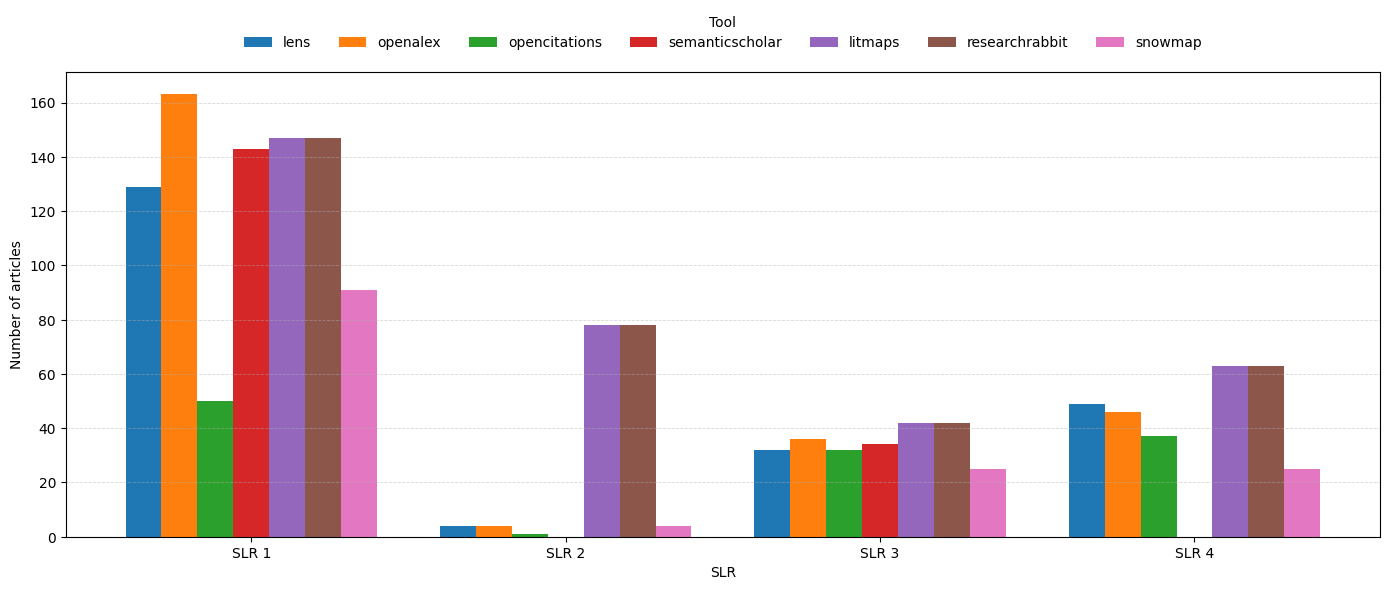

In [ ]:
plot_slr1 = prepare_plot_df(summary_df1, "SLR 1")
plot_slr2 = prepare_plot_df(summary_df2, "SLR 2")
plot_slr3 = prepare_plot_df(summary_df3, "SLR 3")
plot_slr4 = prepare_plot_df(summary_df4, "SLR 4")

plot_df = pd.concat([plot_slr1, plot_slr2, plot_slr3, plot_slr4], ignore_index=True)
plot_df
plot_articles_by_tool_and_slr(plot_df)


### **MISSING DATA ANALYSIS**

SUMMARY OF MISSING DATAS

In [ ]:
# unione
missing_all = combine_missing_summaries(
    missing_df1, missing_df2, missing_df3, missing_df4
)

display(missing_all)


,file,tool,rows_total,missing_doi_pct,missing_abstract_pct,missing_venue_pct,missing_cited_by_pct,missing_year_pct,error,slr
0,artigo01_lens.csv,lens,129,13.953488,10.077519,7.751938,0.000000,0.000000,None,SLR 1
1,artigo01_litmaps.csv,litmaps,147,12.925170,16.326531,12.925170,0.000000,0.000000,None,SLR 1
2,artigo01_openalex.csv,openalex,163,7.975460,82.822086,58.282209,0.000000,0.000000,None,SLR 1
3,artigo01_opencitations.csv,opencitations,50,0.000000,100.000000,100.000000,100.000000,0.000000,None,SLR 1
4,artigo01_researchrabbit.csv,researchrabbit,147,100.000000,16.326531,12.925170,0.000000,0.000000,None,SLR 1
5,artigo01_semanticscholar.csv,semanticscholar,143,5.594406,67.132867,11.888112,5.594406,4.895105,None,SLR 1
6,artigo01_snowmap.csv,snowmap,91,0.000000,97.802198,19.780220,0.000000,0.000000,None,SLR 1
7,artigo02_lens.csv,lens,4,25.000000,0.000000,25.000000,0.000000,0.000000,None,SLR 2
8,artigo02_litmaps.csv,litmaps,78,24.358974,14.102564,32.051282,0.000000,0.000000,None,SLR 2
9,artigo02_openalex.csv,openalex,4,0.000000,75.000000,75.000000,0.000000,0.000000,None,SLR 2


In [ ]:
output_csv_path = "missing_all_summary.csv"
missing_all.to_csv(output_csv_path, index=False)
print(f"The 'missing_all' DataFrame has been downloaded as {output_csv_path}")

The 'missing_all' DataFrame has been downloaded as missing_all_summary.csv


PLOT OF MISSING DATA IN ARTICLE 1


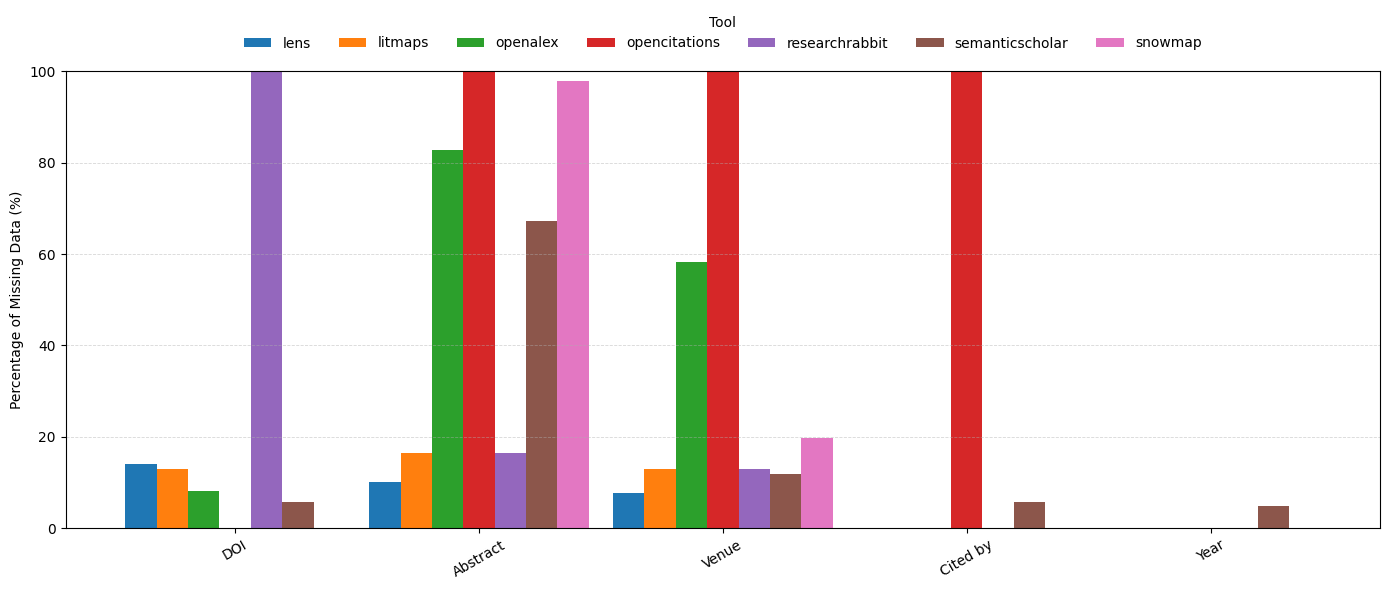

In [ ]:
plot_missing_by_field_and_tool(missing_df1)

PLOT OF MISSING DATA IN ARTICLE 2

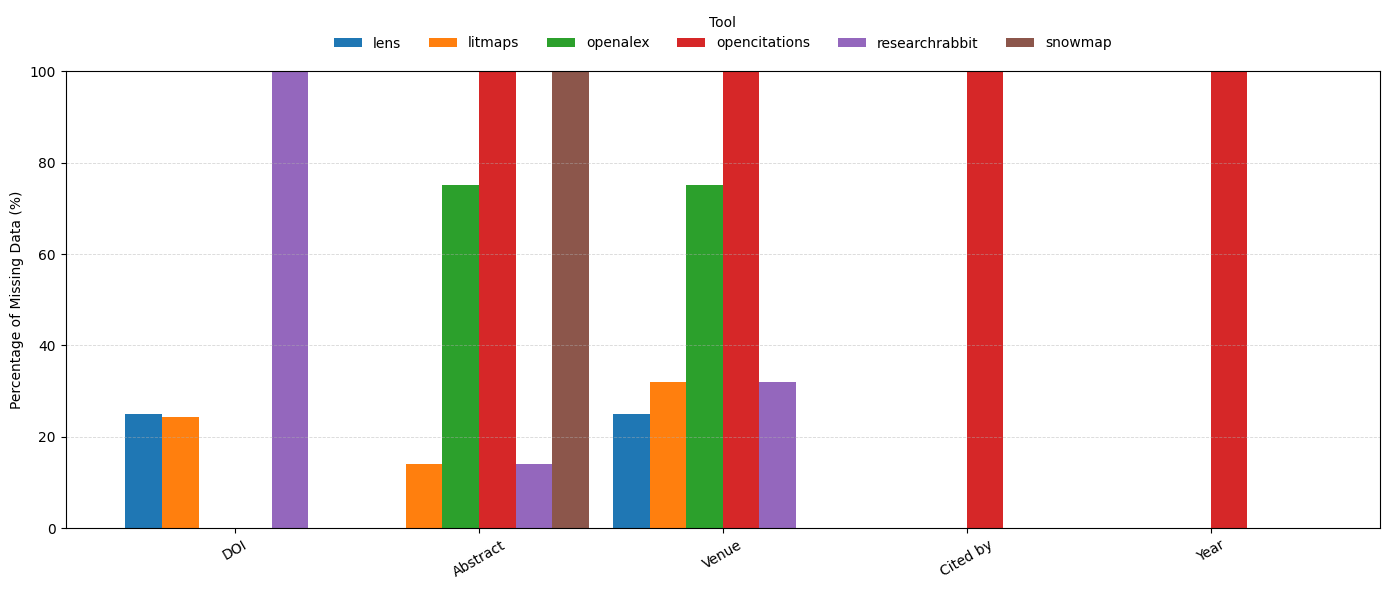

In [ ]:
plot_missing_by_field_and_tool(missing_df2)

PLOT OF MISSING DATA IN ARTICLE 3

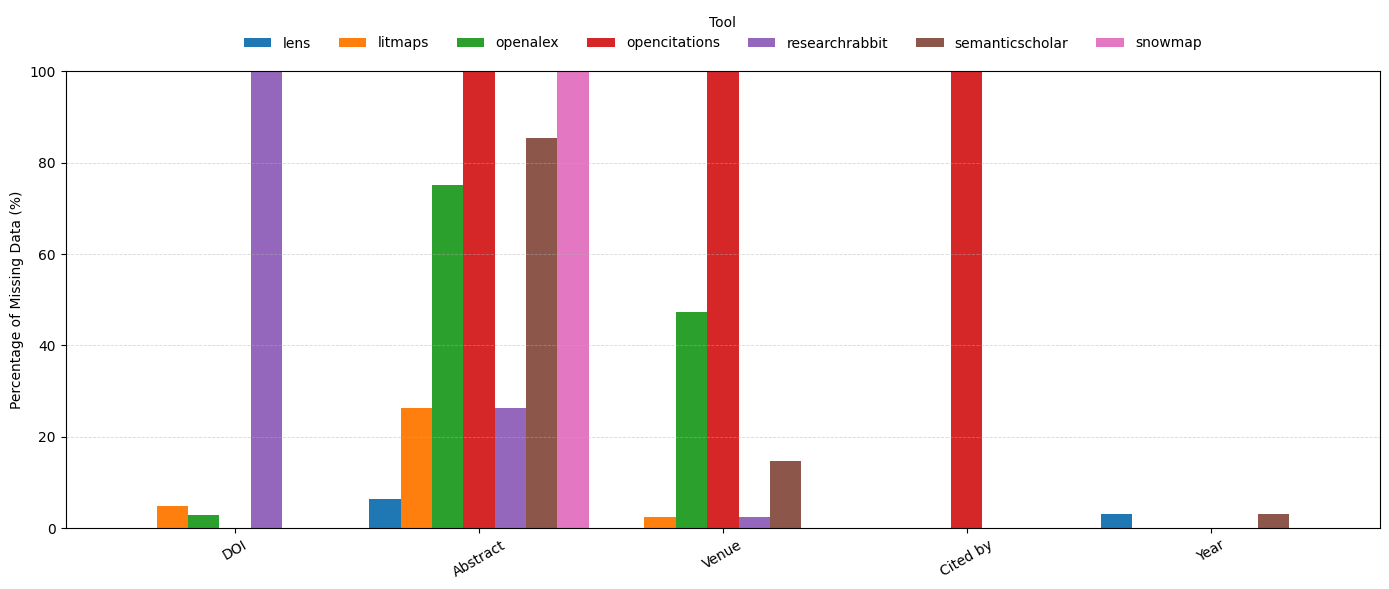

In [ ]:
plot_missing_by_field_and_tool(missing_df3)

PLOT OF MISSING DATA IN ARTICLE 4

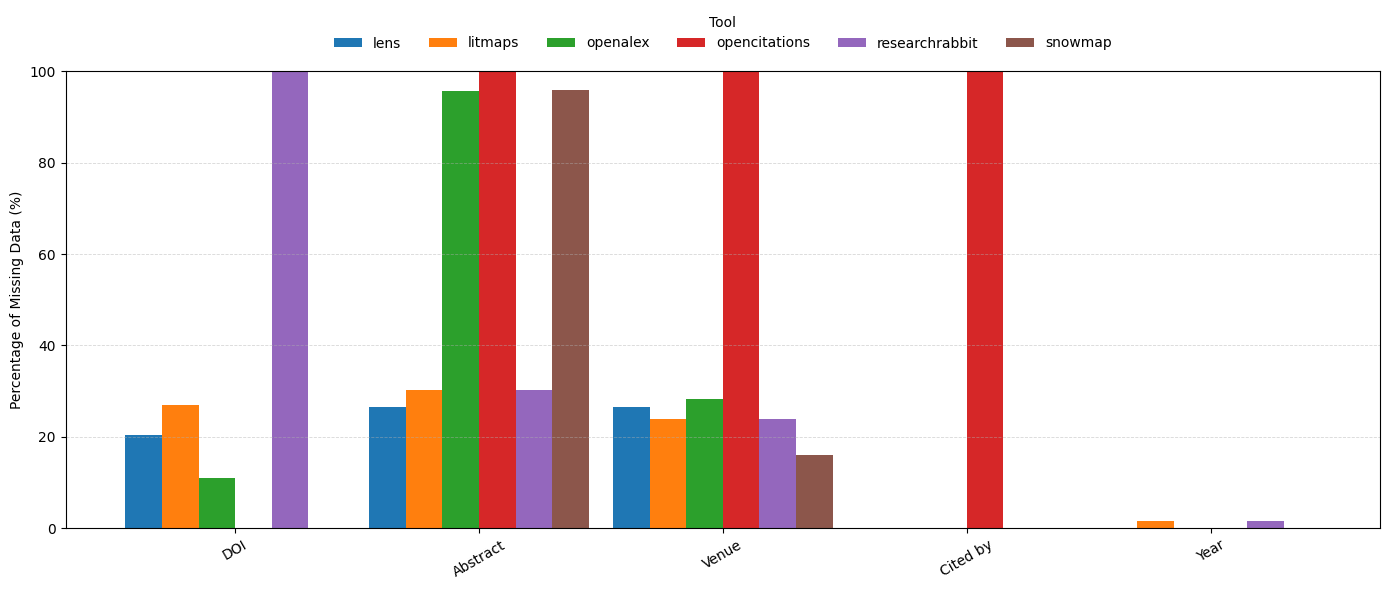

In [ ]:
plot_missing_by_field_and_tool(missing_df4)

In [ ]:
TOOL_ORDER = [
    #"googlescholar",
    "lens",
    "openalex",
    "opencitations",
    "semanticscholar",
    "litmaps",
    "researchrabbit",
    "snowmap"
]

FIELD_ORDER = ["Abstract", "Cited by", "DOI", "Venue", "Year"]
palette = plt.get_cmap("tab10")
TOOL_COLORS = {tool: palette(i) for i, tool in enumerate(TOOL_ORDER)}
def plot_4_missing_charts(missing_dfs, titles):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)
    axes = axes.flatten()

    handles, labels = None, None
    field_order = ["Abstract", "Cited by", "DOI", "Venue", "Year"]

    for ax, df, title in zip(axes, missing_dfs, titles):
        pivot_df = df.pivot(index="field", columns="tool", values="missing_pct")

        pivot_df.index = [str(i).strip() for i in pivot_df.index]
        pivot_df = pivot_df.reindex(field_order).fillna(0)

        pivot_df.columns = [str(c).strip().lower() for c in pivot_df.columns]
        pivot_df = pivot_df.reindex(columns=TOOL_ORDER, fill_value=0)

        pivot_df.plot(
            kind="bar",
            ax=ax,
            color=[TOOL_COLORS[t] for t in TOOL_ORDER],
            width=0.82
        )

        ax.set_title(title, fontsize=14, fontweight="bold", pad=6)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(field_order, rotation=25, ha="right", fontsize=12, color="black")

        ax.tick_params(axis="y", labelsize=11, colors="black")
        ax.tick_params(axis="x", colors="black")

        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.grid(axis="x", visible=False)

        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    axes[0].set_ylabel("Percentage of Missing Data (%)", fontsize=12, color="black")
    axes[2].set_ylabel("Percentage of Missing Data (%)", fontsize=12, color="black")

    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=8,
        title="Tool",
        bbox_to_anchor=(0.5, 1.05),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

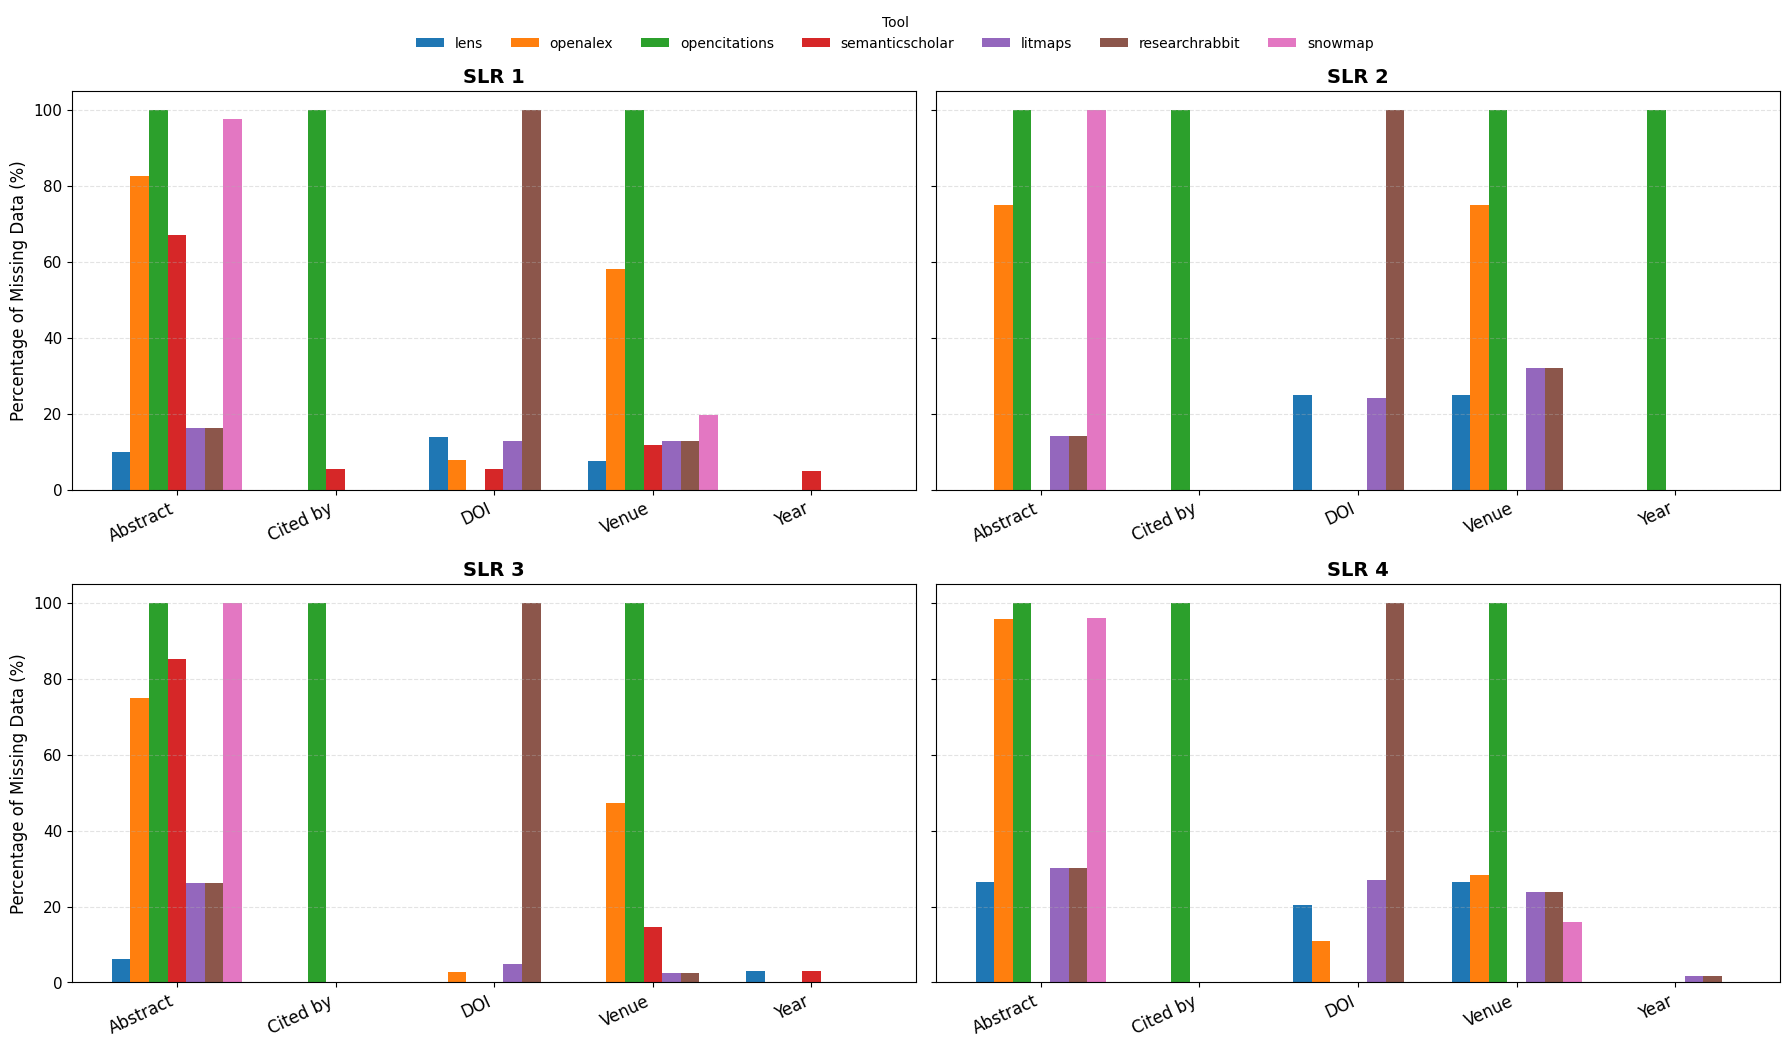

In [ ]:
def prepare_for_plotting_multiple_slr(missing_summary_df):
    if missing_summary_df.empty:
        return pd.DataFrame(columns=["tool", "field", "missing_pct"])

    melted_df = missing_summary_df.melt(
        id_vars=['tool'],
        value_vars=list(MISSING_COL_MAP.keys()),
        var_name='field_raw',
        value_name='missing_pct'
    )

    melted_df['field'] = melted_df['field_raw'].map(MISSING_COL_MAP)

    # Aggregate to ensure unique (tool, field) combinations
    # Use mean to handle cases where a tool might have multiple files,
    # averaging their missing percentages for the same field.
    result_df = melted_df.groupby(['tool', 'field'], as_index=False)['missing_pct'].mean()

    return result_df[['tool', 'field', 'missing_pct']]

#preparing each df
prepared_missing_df1 = prepare_for_plotting_multiple_slr(missing_df1)
prepared_missing_df2 = prepare_for_plotting_multiple_slr(missing_df2)
prepared_missing_df3 = prepare_for_plotting_multiple_slr(missing_df3)
prepared_missing_df4 = prepare_for_plotting_multiple_slr(missing_df4)


plot_4_missing_charts(
    [prepared_missing_df1, prepared_missing_df2, prepared_missing_df3, prepared_missing_df4],
    ["SLR 1", "SLR 2", "SLR 3", "SLR 4"]
)

### **Snowmap: Righe con Dati 'Cited by' Mancanti**

In [ ]:
print("Analisi dei dati 'Cited by' mancanti per Snowmap...")

# Assuming 'missing_all' DataFrame is already populated from previous steps
# and 'CSV_BASE' is defined, if not, adjust path construction.

# Use a placeholder for CSV_BASE if it's not explicitly defined globally,
# or ensure it's set from existing notebook variables if appropriate.
# From the notebook state, it looks like `base` is '/content/drive/MyDrive/estudos_snowbaling'.
# Let's use `base` to construct folder paths.

for index, row in missing_all.iterrows():
    if row['tool'] == 'snowmap' and row['missing_cited_by_pct'] > 0:
        file_name = row['file']
        slr_num = row['slr'].replace('SLR ', '')

        # Constructing the folder path using the base variable
        folder_path = Path(base) / f"new_csvs_slr0{slr_num}"
        csv_path = folder_path / file_name

        print(f"\nProcessing file: {file_name} (SLR {slr_num})")

        try:
            df = read_csv_with_fallback(csv_path).copy()
            df.columns = [c.strip() for c in df.columns]

            cited_by_col = find_column_by_candidates(df, [
                "Cited By", "Cited by", "cited_by_count", "citationCount", "cited_by", "Citing Works Count"
            ])

            # Dynamically find title and doi columns
            title_col_name = find_title_column(df)
            doi_col_name = find_doi_column(df)

            cols_to_display = []
            if title_col_name: # Check if a title column was found
                cols_to_display.append(title_col_name)
            if doi_col_name: # Check if a doi column was found
                cols_to_display.append(doi_col_name)
            if cited_by_col: # Always add the cited_by column if it exists
                cols_to_display.append(cited_by_col)

            # Ensure all columns to display actually exist in the dataframe to prevent KeyError
            cols_to_display = [c for c in cols_to_display if c in df.columns]

            if cited_by_col:
                missing_cited_by_rows = df[df[cited_by_col].apply(is_missing_value)]
                if not missing_cited_by_rows.empty:
                    # Modified print statement to include total rows
                    print(f"Found {len(missing_cited_by_rows)} rows with missing '{cited_by_col}' data out of {row['rows_total']} total rows:")
                    # Displaying relevant columns: title, doi, and the actual cited_by column
                    display(missing_cited_by_rows[cols_to_display])
                else:
                    print(f"No missing '{cited_by_col}' data found, despite summary report (might be rounding or specific parsing issue).")
            else:
                print(f"'Cited by' column not found in {file_name}.")

        except Exception as e:
            print(f"Error reading or processing {file_name}: {e}")

print("Analisi completata.")

Analisi dei dati 'Cited by' mancanti per Snowmap...
Analisi completata.


### **Articoli Mancanti 'Cited by' in Snowmap e OpenAlex**

In [ ]:
def find_common_missing_cited_by(folder_path: Path, slr_name: str):
    snowmap_file = None
    openalex_file = None

    # Find Snowmap and OpenAlex files in the current folder
    for p in folder_path.iterdir():
        if p.is_file() and p.suffix.lower() == ".csv":
            stem = p.stem.lower()
            if "snowmap" in stem:
                snowmap_file = p
            elif "openalex" in stem:
                openalex_file = p

    if not snowmap_file or not openalex_file:
        print(f"Skipping {slr_name}: Snowmap or OpenAlex file not found in {folder_path.name}")
        return pd.DataFrame()

    print(f"\nProcessing {slr_name} for Snowmap and OpenAlex...")

    # --- Process Snowmap data (identify records missing 'Cited by') ---
    df_snowmap, _, _ = prepare_normalized_df(snowmap_file, verbose=False)
    snowmap_cited_by_col = find_column_by_candidates(df_snowmap, [
        "Cited By", "Cited by", "cited_by_count", "citationCount", "cited_by", "Citing Works Count"
    ])
    missing_snowmap_cited_by = pd.DataFrame()
    if snowmap_cited_by_col:
        missing_snowmap_cited_by = df_snowmap[df_snowmap[snowmap_cited_by_col].apply(is_missing_value)].copy()
        if not missing_snowmap_cited_by.empty:
            missing_snowmap_cited_by = missing_snowmap_cited_by[['doi_norm', 'title_norm']].drop_duplicates().dropna(how='all')
        print(f"  {slr_name} Snowmap: Found {len(missing_snowmap_cited_by)} unique records with missing 'Cited by'.")

    # --- Process OpenAlex data (load all records for comparison) ---
    df_openalex, _, _ = prepare_normalized_df(openalex_file, verbose=False)
    # We only need the identifiers from OpenAlex for matching
    openalex_identifiers = df_openalex[['doi_norm', 'title_norm']].drop_duplicates().dropna(how='all')
    print(f"  {slr_name} OpenAlex: Loaded {len(openalex_identifiers)} unique records for comparison.")

    # --- Find Snowmap records (missing 'Cited by') that are present in OpenAlex ---
    if not missing_snowmap_cited_by.empty:
        # Records from missing_snowmap_cited_by that have a DOI
        snowmap_with_doi = missing_snowmap_cited_by.dropna(subset=['doi_norm'])
        # Records from missing_snowmap_cited_by that do NOT have a DOI but have a title
        snowmap_without_doi_with_title = missing_snowmap_cited_by[
            missing_snowmap_cited_by['doi_norm'].isna()
        ].dropna(subset=['title_norm'])

        # Records from openalex_identifiers that have a DOI
        openalex_with_doi = openalex_identifiers.dropna(subset=['doi_norm'])
        # Records from openalex_identifiers that do NOT have a DOI but have a title
        openalex_without_doi_with_title = openalex_identifiers[
            openalex_identifiers['doi_norm'].isna()
        ].dropna(subset=['title_norm'])


        # Match by DOI
        common_by_doi = pd.merge(
            snowmap_with_doi,
            openalex_with_doi,
            on='doi_norm',
            how='inner',
            suffixes=('_snowmap', '_openalex')
        )
        # We only care about the original Snowmap record's identifiers
        common_by_doi_result = common_by_doi[['doi_norm', 'title_norm_snowmap']].rename(columns={'title_norm_snowmap': 'title_norm'})


        # Match by Title (for records where DOI is missing)
        common_by_title = pd.merge(
            snowmap_without_doi_with_title,
            openalex_without_doi_with_title,
            on='title_norm',
            how='inner',
            suffixes=('_snowmap', '_openalex')
        )
        # We only care about the original Snowmap record's identifiers
        common_by_title_result = common_by_title[['doi_norm_snowmap', 'title_norm']].rename(columns={'doi_norm_snowmap': 'doi_norm'})

        # Combine results from both matching methods
        common_records = pd.concat([common_by_doi_result, common_by_title_result]).drop_duplicates().reset_index(drop=True)
        common_records['SLR'] = slr_name
        print(f"  {slr_name} Common: Found {len(common_records)} Snowmap records missing 'Cited by' that are present in OpenAlex.")
        return common_records

    print(f"  {slr_name} Common: No Snowmap records missing 'Cited by' found to compare.")
    return pd.DataFrame()

all_common_missing = []

# Assuming 'base' is defined as the root path, e.g., '/content/drive/MyDrive/estudos_snowbaling'
# You might need to adjust this if `base` is not globally available or if the folder structure is different

slr_folders = {
    "SLR 1": Path(base) / "new_csvs_slr01",
    "SLR 2": Path(base) / "new_csvs_slr02",
    "SLR 3": Path(base) / "new_csvs_slr03",
    "SLR 4": Path(base) / "new_csvs_slr04",
}

for slr_name, folder_path in slr_folders.items():
    common_df = find_common_missing_cited_by(folder_path, slr_name)
    if not common_df.empty:
        all_common_missing.append(common_df)

if all_common_missing:
    final_common_df = pd.concat(all_common_missing, ignore_index=True)
    print("\n--- Riassunto finale degli articoli comuni con 'Cited by' mancanti ---\n(Questi sono i record di Snowmap con 'Cited by' mancante che sono stati trovati in OpenAlex)")
    display(final_common_df)
else:
    print("\nNessun articolo trovato con 'Cited by' mancante in Snowmap che sia presente in OpenAlex per gli SLR analizzati.")

In [ ]:
def get_openalex_cited_by_for_common_articles(common_articles_df: pd.DataFrame):
    results = []

    if common_articles_df.empty:
        print("Nessun articolo comune trovato per cui recuperare i dati 'Cited by' da OpenAlex.")
        return pd.DataFrame()

    # Group by SLR to process files only once per SLR
    for slr_name, group_df in common_articles_df.groupby('SLR'):
        slr_num = slr_name.replace('SLR ', '')
        folder_path = Path(base) / f"new_csvs_slr0{slr_num}"

        openalex_file = None
        for p in folder_path.iterdir():
            if p.is_file() and p.suffix.lower() == ".csv" and "openalex" in p.stem.lower():
                openalex_file = p
                break

        if not openalex_file:
            print(f"[WARNING] OpenAlex file non trovato per {slr_name} in {folder_path.name}")
            continue

        try:
            df_openalex, _, _ = prepare_normalized_df(openalex_file, verbose=False)
            openalex_cited_by_col = find_column_by_candidates(df_openalex, [
                "Cited By", "Cited by", "cited_by_count", "citationCount", "cited_by", "Citing Works Count"
            ])

            if openalex_cited_by_col is None:
                print(f"[WARNING] Colonna 'Cited by' non trovata nel file OpenAlex per {slr_name}: {openalex_file.name}")
                # For articles in this SLR, we can add a default 'N/A' or similar
                for _, row in group_df.iterrows():
                    results.append({
                        'SLR': row['SLR'],
                        'Snowmap_DOI_norm': row['doi_norm'],
                        'Snowmap_Title_norm': row['title_norm'],
                        'OpenAlex_Cited_by_Value': 'N/A (Column Missing)'
                    })
                continue

            for _, common_row in group_df.iterrows():
                matched_openalex_records = pd.DataFrame()
                # Try to match by DOI first
                if pd.notna(common_row['doi_norm']):
                    matched_openalex_records = df_openalex[df_openalex['doi_norm'] == common_row['doi_norm']]

                # If no match by DOI or DOI is missing, try matching by Title
                if matched_openalex_records.empty and pd.notna(common_row['title_norm']):
                    matched_openalex_records = df_openalex[df_openalex['title_norm'] == common_row['title_norm']]

                cited_by_value = None
                if not matched_openalex_records.empty:
                    # Take the first matched record's 'Cited by' value
                    # (assuming unique articles after normalization)
                    value = matched_openalex_records.iloc[0][openalex_cited_by_col]
                    # Convert to string and handle potential missing tokens if necessary
                    if is_missing_value(value):
                        cited_by_value = 'Missing'
                    else:
                        cited_by_value = value
                else:
                    cited_by_value = 'Not found in OpenAlex'

                results.append({
                    'SLR': common_row['SLR'],
                    'Snowmap_DOI_norm': common_row['doi_norm'],
                    'Snowmap_Title_norm': common_row['title_norm'],
                    'OpenAlex_Cited_by_Value': cited_by_value
                })

        except Exception as e:
            print(f"[ERROR] Errore durante l'elaborazione del file OpenAlex {openalex_file.name} per {slr_name}: {e}")

    return pd.DataFrame(results)

# Esegui la funzione con il DataFrame degli articoli comuni
openalex_cited_by_common = get_openalex_cited_by_for_common_articles(final_common_df)

if not openalex_cited_by_common.empty:
    print("\n--- Valori 'Cited by' da OpenAlex per gli articoli comuni (Snowmap missing 'Cited by' -> OpenAlex found) ---")
    display(openalex_cited_by_common)
else:
    print("\nNessun valore 'Cited by' recuperato da OpenAlex per gli articoli comuni.")

### **Articoli 'Cited by' Mancanti in Snowmap (Non Trovati in OpenAlex o Semantic Scholar)**

In [ ]:
def get_snowmap_missing_cited_by(folder_path: Path, slr_name: str):
    snowmap_file = None

    for p in folder_path.iterdir():
        if p.is_file() and p.suffix.lower() == ".csv" and "snowmap" in p.stem.lower():
            snowmap_file = p
            break

    if not snowmap_file:
        print(f"Skipping {slr_name}: Snowmap file not found in {folder_path.name}")
        return pd.DataFrame()

    df_snowmap, _, _ = prepare_normalized_df(snowmap_file, verbose=False)
    snowmap_cited_by_col = find_column_by_candidates(df_snowmap, [
        "Cited By", "Cited by", "cited_by_count", "citationCount", "cited_by", "Citing Works Count"
    ])

    missing_snowmap_cited_by = pd.DataFrame()
    if snowmap_cited_by_col:
        missing_snowmap_cited_by = df_snowmap[df_snowmap[snowmap_cited_by_col].apply(is_missing_value)].copy()
        if not missing_snowmap_cited_by.empty:
            missing_snowmap_cited_by = missing_snowmap_cited_by[['doi_norm', 'title_norm']].drop_duplicates().dropna(how='all')
            missing_snowmap_cited_by['SLR'] = slr_name
        # print(f"  {slr_name} Snowmap: Found {len(missing_snowmap_cited_by)} unique records with missing 'Cited by'.")

    return missing_snowmap_cited_by


all_snowmap_missing_cited_by = []

for slr_name, folder_path in slr_folders.items():
    snowmap_missing_df = get_snowmap_missing_cited_by(folder_path, slr_name)
    if not snowmap_missing_df.empty:
        all_snowmap_missing_cited_by.append(snowmap_missing_df)

all_snowmap_missing_cited_by_df = pd.concat(all_snowmap_missing_cited_by, ignore_index=True)
print(f"Totale articoli Snowmap con 'Cited by' mancante: {len(all_snowmap_missing_cited_by_df)}")
display(all_snowmap_missing_cited_by_df.head())


In [ ]:
def find_common_missing_cited_by_with_semanticscholar(folder_path: Path, slr_name: str):
    snowmap_file = None
    semanticscholar_file = None

    # Find Snowmap and Semantic Scholar files in the current folder
    for p in folder_path.iterdir():
        if p.is_file() and p.suffix.lower() == ".csv":
            stem = p.stem.lower()
            if "snowmap" in stem:
                snowmap_file = p
            elif "semanticscholar" in stem:
                semanticscholar_file = p

    if not snowmap_file or not semanticscholar_file:
        print(f"Skipping {slr_name}: Snowmap or Semantic Scholar file not found in {folder_path.name}")
        return pd.DataFrame()

    print(f"\nProcessing {slr_name} for Snowmap and Semantic Scholar...")

    # --- Process Snowmap data (identify records missing 'Cited by') ---
    df_snowmap, _, _ = prepare_normalized_df(snowmap_file, verbose=False)
    snowmap_cited_by_col = find_column_by_candidates(df_snowmap, [
        "Cited By", "Cited by", "cited_by_count", "citationCount", "cited_by", "Citing Works Count"
    ])
    missing_snowmap_cited_by = pd.DataFrame()
    if snowmap_cited_by_col:
        missing_snowmap_cited_by = df_snowmap[df_snowmap[snowmap_cited_by_col].apply(is_missing_value)].copy()
        if not missing_snowmap_cited_by.empty:
            missing_snowmap_cited_by = missing_snowmap_cited_by[['doi_norm', 'title_norm']].drop_duplicates().dropna(how='all')
        print(f"  {slr_name} Snowmap: Found {len(missing_snowmap_cited_by)} unique records with missing 'Cited by'.")

    # --- Process Semantic Scholar data (load all records for comparison) ---
    df_semanticscholar, _, _ = prepare_normalized_df(semanticscholar_file, verbose=False)
    # We only need the identifiers from Semantic Scholar for matching
    semanticscholar_identifiers = df_semanticscholar[['doi_norm', 'title_norm']].drop_duplicates().dropna(how='all')
    print(f"  {slr_name} Semantic Scholar: Loaded {len(semanticscholar_identifiers)} unique records for comparison.")

    # --- Find Snowmap records (missing 'Cited by') that are present in Semantic Scholar ---
    if not missing_snowmap_cited_by.empty:
        # Records from missing_snowmap_cited_by that have a DOI
        snowmap_with_doi = missing_snowmap_cited_by.dropna(subset=['doi_norm'])
        # Records from missing_snowmap_cited_by that do NOT have a DOI but have a title
        snowmap_without_doi_with_title = missing_snowmap_cited_by[
            missing_snowmap_cited_by['doi_norm'].isna()
        ].dropna(subset=['title_norm'])

        # Records from semanticscholar_identifiers that have a DOI
        semanticscholar_with_doi = semanticscholar_identifiers.dropna(subset=['doi_norm'])
        # Records from semanticscholar_identifiers that do NOT have a DOI but have a title
        semanticscholar_without_doi_with_title = semanticscholar_identifiers[
            semanticscholar_identifiers['doi_norm'].isna()
        ].dropna(subset=['title_norm'])


        # Match by DOI
        common_by_doi = pd.merge(
            snowmap_with_doi,
            semanticscholar_with_doi,
            on='doi_norm',
            how='inner',
            suffixes=('_snowmap', '_semanticscholar')
        )
        # We only care about the original Snowmap record's identifiers
        common_by_doi_result = common_by_doi[['doi_norm', 'title_norm_snowmap']].rename(columns={'title_norm_snowmap': 'title_norm'})


        # Match by Title (for records where DOI is missing)
        common_by_title = pd.merge(
            snowmap_without_doi_with_title,
            semanticscholar_without_doi_with_title,
            on='title_norm',
            how='inner',
            suffixes=('_snowmap', '_semanticscholar')
        )
        # We only care about the original Snowmap record's identifiers
        common_by_title_result = common_by_title[['doi_norm_snowmap', 'title_norm']].rename(columns={'doi_norm_snowmap': 'doi_norm'})

        # Combine results from both matching methods
        common_records = pd.concat([common_by_doi_result, common_by_title_result]).drop_duplicates().reset_index(drop=True)
        common_records['SLR'] = slr_name
        print(f"  {slr_name} Common: Found {len(common_records)} Snowmap records missing 'Cited by' that are present in Semantic Scholar.")
        return common_records

    print(f"  {slr_name} Common: No Snowmap records missing 'Cited by' found to compare.")
    return pd.DataFrame()

all_common_missing_ss = []

for slr_name, folder_path in slr_folders.items():
    common_df_ss = find_common_missing_cited_by_with_semanticscholar(folder_path, slr_name)
    if not common_df_ss.empty:
        all_common_missing_ss.append(common_df_ss)

if all_common_missing_ss:
    final_common_df_ss = pd.concat(all_common_missing_ss, ignore_index=True)
    print("\n--- Riassunto finale degli articoli comuni con 'Cited by' mancanti ---\n(Questi sono i record di Snowmap con 'Cited by' mancante che sono stati trovati in Semantic Scholar)")
    display(final_common_df_ss)
else:
    print("\nNessun articolo trovato con 'Cited by' mancante in Snowmap che sia presente in Semantic Scholar per gli SLR analizzati.")

In [ ]:
# Combinare i risultati di OpenAlex e Semantic Scholar

# Ensure final_common_df_ss is defined, even if empty
import pandas as pd
if 'final_common_df_ss' not in locals() and 'final_common_df_ss' not in globals():
    final_common_df_ss = pd.DataFrame()

combined_openalex_ss = pd.concat([final_common_df, final_common_df_ss], ignore_index=True).drop_duplicates().reset_index(drop=True)
print(f"Totale articoli trovati in OpenAlex o Semantic Scholar (con 'Cited by' mancante in Snowmap): {len(combined_openalex_ss)}")
display(combined_openalex_ss.head())

# Trovare gli articoli Snowmap con 'Cited by' mancante che non sono in combined_openalex_ss
# Usiamo merge con indicator=True per identificare le righe che sono solo in 'left' (all_snowmap_missing_cited_by_df)
merged_df = pd.merge(
    all_snowmap_missing_cited_by_df,
    combined_openalex_ss,
    on=['doi_norm', 'title_norm', 'SLR'],
    how='left',
    indicator=True
)

snowmap_only_missing = merged_df[merged_df['_merge'] == 'left_only'].drop(columns=['_merge'])

print("\n--- Articoli 'Cited by' mancanti in Snowmap e non trovati in OpenAlex o Semantic Scholar ---")
if not snowmap_only_missing.empty:
    display(snowmap_only_missing)
else:
    print("Nessun articolo di Snowmap con 'Cited by' mancante trovato che non sia presente in OpenAlex o Semantic Scholar.")

In [ ]:
# Scarica il DataFrame snowmap_only_missing come file Excel
output_file_path = "snowmap_only_missing_cited_by.xlsx"
snowmap_only_missing.to_excel(output_file_path, index=False)
print(f"Il DataFrame 'snowmap_only_missing' è stato scaricato come {output_file_path}")

### **Valori 'Cited by' da Semantic Scholar per gli Articoli Comuni**

In [ ]:
def get_semanticscholar_cited_by_for_common_articles(common_articles_df: pd.DataFrame):
    results = []

    if common_articles_df.empty:
        print("Nessun articolo comune trovato per cui recuperare i dati 'Cited by' da Semantic Scholar.")
        return pd.DataFrame()

    for slr_name, group_df in common_articles_df.groupby('SLR'):
        slr_num = slr_name.replace('SLR ', '')
        folder_path = Path(base) / f"new_csvs_slr0{slr_num}"

        semanticscholar_file = None
        for p in folder_path.iterdir():
            if p.is_file() and p.suffix.lower() == ".csv" and "semanticscholar" in p.stem.lower():
                semanticscholar_file = p
                break

        if not semanticscholar_file:
            print(f"[WARNING] Semantic Scholar file non trovato per {slr_name} in {folder_path.name}")
            continue

        try:
            df_semanticscholar, _, _ = prepare_normalized_df(semanticscholar_file, verbose=False)
            semanticscholar_cited_by_col = find_column_by_candidates(df_semanticscholar, [
                "Cited By", "Cited by", "cited_by_count", "citationCount", "cited_by", "Citing Works Count"
            ])

            if semanticscholar_cited_by_col is None:
                print(f"[WARNING] Colonna 'Cited by' non trovata nel file Semantic Scholar per {slr_name}: {semanticscholar_file.name}")
                for _, row in group_df.iterrows():
                    results.append({
                        'SLR': row['SLR'],
                        'Snowmap_DOI_norm': row['doi_norm'],
                        'Snowmap_Title_norm': row['title_norm'],
                        'SemanticScholar_Cited_by_Value': 'N/A (Column Missing)'
                    })
                continue

            for _, common_row in group_df.iterrows():
                matched_semanticscholar_records = pd.DataFrame()
                if pd.notna(common_row['doi_norm']):
                    matched_semanticscholar_records = df_semanticscholar[df_semanticscholar['doi_norm'] == common_row['doi_norm']]

                if matched_semanticscholar_records.empty and pd.notna(common_row['title_norm']):
                    matched_semanticscholar_records = df_semanticscholar[df_semanticscholar['title_norm'] == common_row['title_norm']]

                cited_by_value = None
                if not matched_semanticscholar_records.empty:
                    value = matched_semanticscholar_records.iloc[0][semanticscholar_cited_by_col]
                    if is_missing_value(value):
                        cited_by_value = 'Missing'
                    else:
                        cited_by_value = value
                else:
                    cited_by_value = 'Not found in Semantic Scholar'

                results.append({
                    'SLR': common_row['SLR'],
                    'Snowmap_DOI_norm': common_row['doi_norm'],
                    'Snowmap_Title_norm': common_row['title_norm'],
                    'SemanticScholar_Cited_by_Value': cited_by_value
                })

        except Exception as e:
            print(f"[ERROR] Errore durante l'elaborazione del file Semantic Scholar {semanticscholar_file.name} per {slr_name}: {e}")

    return pd.DataFrame(results)

semanticscholar_cited_by_common = get_semanticscholar_cited_by_for_common_articles(final_common_df_ss)

if not semanticscholar_cited_by_common.empty:
    print("\n--- Valori 'Cited by' da Semantic Scholar per gli articoli comuni (Snowmap missing 'Cited by' -> Semantic Scholar found) ---")
    display(semanticscholar_cited_by_common)
else:
    print("\nNessun valore 'Cited by' recuperato da Semantic Scholar per gli articoli comuni.")

### Applying exclusion for `g-t_artigo01.csv` in SLR1

In [ ]:
print('Re-running duplicate analysis for SLR1 with g-t_artigo01.csv excluded:')
folder1 = Path(base) / "new_csvs_slr01"

summary_df1, duplicate_doi_details, duplicate_title_details, duplicate_table_df = analyze_duplicates_in_folder(folder1)
display(summary_df1)

In [ ]:
print('Re-running missing data analysis for SLR1 with g-t_artigo01.csv excluded:')
missing_df1 = analyze_missing_in_folder(folder1)
missing_df1 = prepare_missing_plot_df(missing_df1, "SLR 1")
display(missing_df1)

In [ ]:
print('Updating overall article count plot:')
plot_slr1 = prepare_plot_df(summary_df1, "SLR 1")
plot_slr2 = prepare_plot_df(summary_df2, "SLR 2")
plot_slr3 = prepare_plot_df(summary_df3, "SLR 3")
plot_slr4 = prepare_plot_df(summary_df4, "SLR 4")

plot_df = pd.concat([plot_slr1, plot_slr2, plot_slr3, plot_slr4], ignore_index=True)
display(plot_df)
plot_articles_by_tool_and_slr(plot_df)

Updating overall missing data summary and plots:


,file,tool,rows_total,missing_doi_pct,missing_abstract_pct,missing_venue_pct,missing_cited_by_pct,missing_year_pct,error,slr
0,artigo01_lens.csv,lens,129,13.953488,10.077519,7.751938,0.000000,0.000000,None,SLR 1
1,artigo01_litmaps.csv,litmaps,147,12.925170,16.326531,12.925170,0.000000,0.000000,None,SLR 1
2,artigo01_openalex.csv,openalex,163,7.975460,82.822086,58.282209,0.000000,0.000000,None,SLR 1
3,artigo01_opencitations.csv,opencitations,50,0.000000,100.000000,100.000000,100.000000,0.000000,None,SLR 1
4,artigo01_researchrabbit.csv,researchrabbit,147,100.000000,16.326531,12.925170,0.000000,0.000000,None,SLR 1
5,artigo01_semanticscholar.csv,semanticscholar,143,5.594406,67.132867,11.888112,5.594406,4.895105,None,SLR 1
6,artigo01_snowmap.csv,snowmap,91,0.000000,97.802198,19.780220,0.000000,0.000000,None,SLR 1
7,artigo02_lens.csv,lens,4,25.000000,0.000000,25.000000,0.000000,0.000000,None,SLR 2
8,artigo02_litmaps.csv,litmaps,78,24.358974,14.102564,32.051282,0.000000,0.000000,None,SLR 2
9,artigo02_openalex.csv,openalex,4,0.000000,75.000000,75.000000,0.000000,0.000000,None,SLR 2


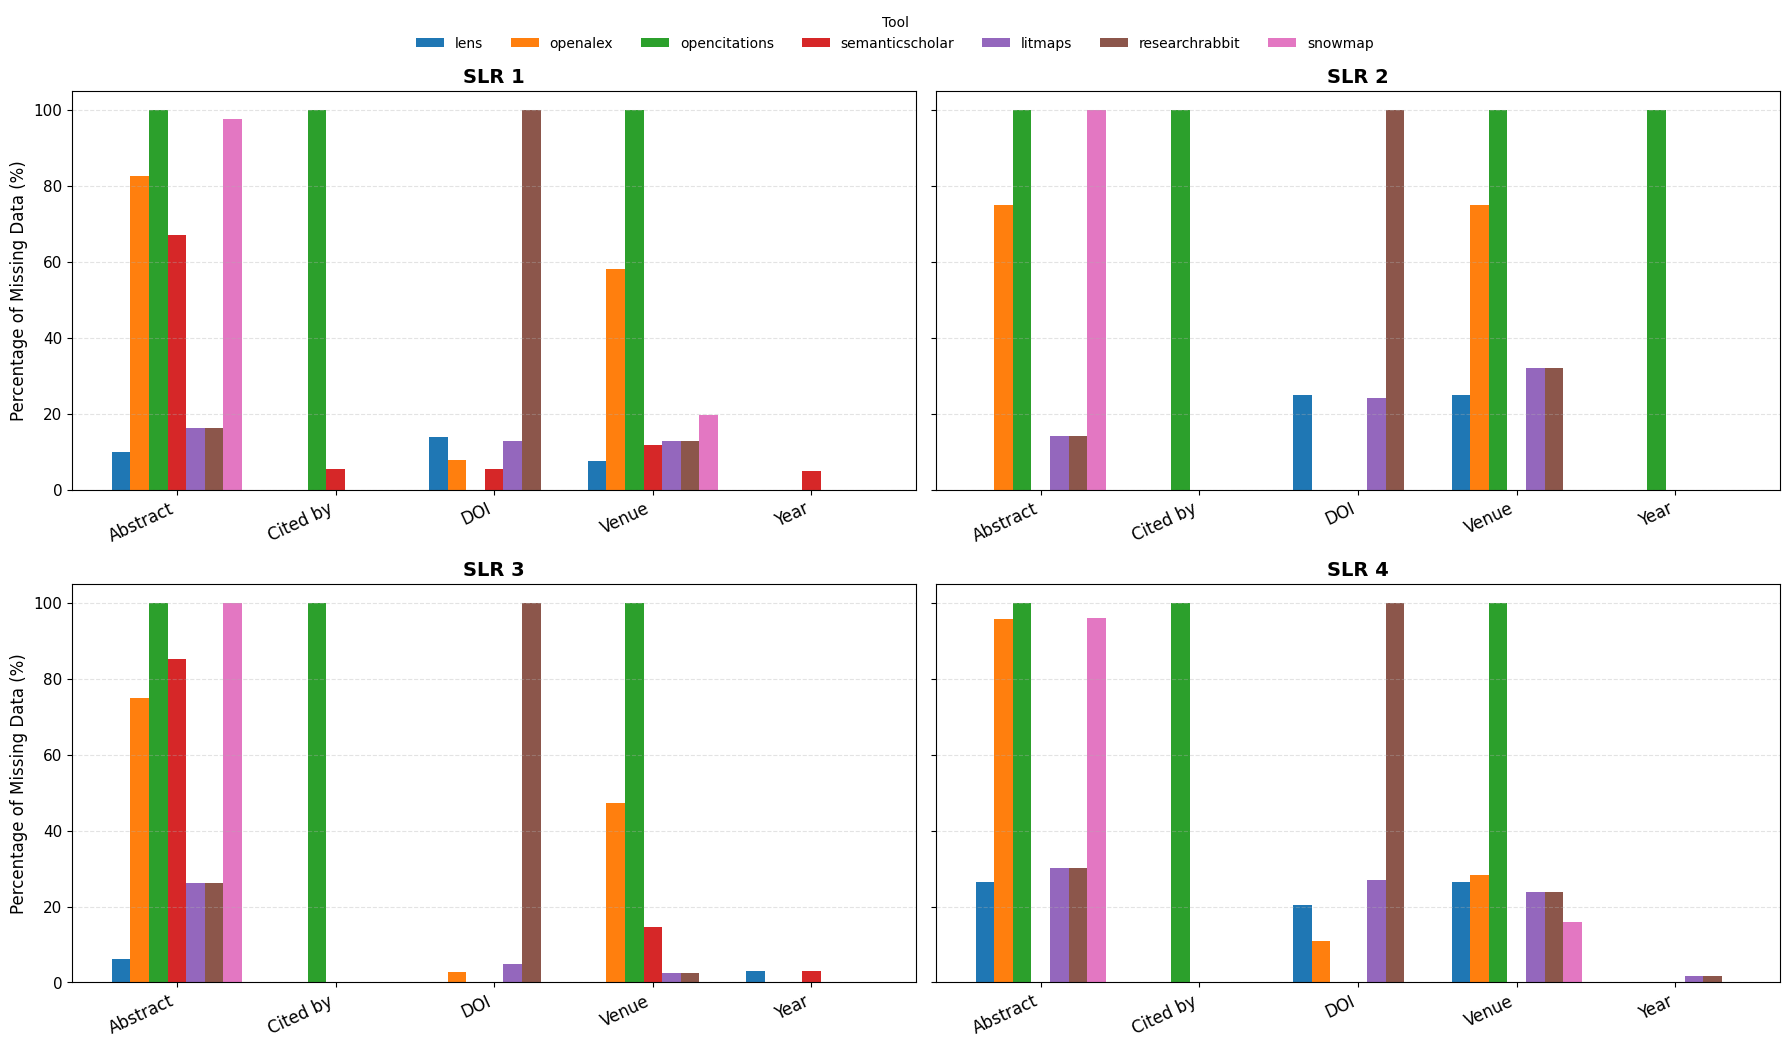

In [ ]:
print('Updating overall missing data summary and plots:')
missing_all = combine_missing_summaries(
    missing_df1, missing_df2, missing_df3, missing_df4
)
display(missing_all)

prepared_missing_df1 = prepare_for_plotting_multiple_slr(missing_df1)
prepared_missing_df2 = prepare_for_plotting_multiple_slr(missing_df2)
prepared_missing_df3 = prepare_for_plotting_multiple_slr(missing_df3)
prepared_missing_df4 = prepare_for_plotting_multiple_slr(missing_df4)

plot_4_missing_charts(
    [prepared_missing_df1, prepared_missing_df2, prepared_missing_df3, prepared_missing_df4],
    ["SLR 1", "SLR 2", "SLR 3", "SLR 4"]
)